# 0.Library

In [20]:
# general
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import re
import importlib

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

# MLFlow
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient

# Paths
import sys
sys.path.append('../') 
from features import data_utils as du
from features import data_pipeline as dp
from features import general_func as gf
import constants_data as cd
from features import model_utils as mu

# Reload
importlib.reload(du)
importlib.reload(dp)
importlib.reload(gf)
importlib.reload(cd)
importlib.reload(mu)

<module 'features.model_utils' from '/home/smira/myproject/detection_AD_with_VR_data/src/notebooks/../features/model_utils.py'>

# 1. Paths and Constants

In [21]:
# different experiments
experiments_list = cd.all_experiments

# Read dataframe
parent_folder = Path("../..") # go 2 folder up= "../.."
df_path = parent_folder / "data" / "produced_csv" / "2.cleaned_features_20_patients.csv"
 
df = pd.read_csv(df_path)

df.head()

,Age,Help_Rating_out_of_5,MoCA_Score,Tutorial_total_reading_time,Tutorial_max_reading_time,Tutorial_intensity_reading_time,Tutorial_total_duration_hover,Tutorial_mean_duration_hover,Tutorial_max_duration_hover,Tutorial_std_duration_hover,...,Memory_Yaw_std,Memory_Pitch_std,Memory_Roll_std,Memory_Yaw_range,Memory_dominant_hand_mean_speed,Memory_not_dominant_hand_mean_speed,Memory_dominant_hand_z_range,Memory_not_dominant_hand_y_range,Gender_Male,dominant_hand_Right
0,73.0,4,28.0,45.03,21.00,0.92,20.64,1.03,2.29,0.74,...,26.23,161.72,177.36,99.05,0.16,0.03,0.82,0.80,0,1
1,59.0,2,27.0,171.99,91.56,0.98,53.05,1.02,13.42,2.25,...,47.08,165.33,172.85,180.39,0.06,0.04,1.02,0.61,0,1
2,82.0,1,26.0,338.75,155.14,0.99,145.79,2.11,20.01,4.20,...,23.27,161.90,162.61,109.38,0.06,0.01,0.98,0.75,1,1
3,75.0,2,27.0,114.78,68.19,0.97,46.90,1.47,13.24,2.97,...,25.75,171.61,101.97,234.99,0.06,0.03,0.50,0.59,1,0
4,62.0,1,27.0,152.90,88.47,0.97,54.33,1.81,11.62,2.66,...,30.07,170.64,169.17,248.93,0.12,0.02,1.05,0.58,1,1


# 2. Data visualization

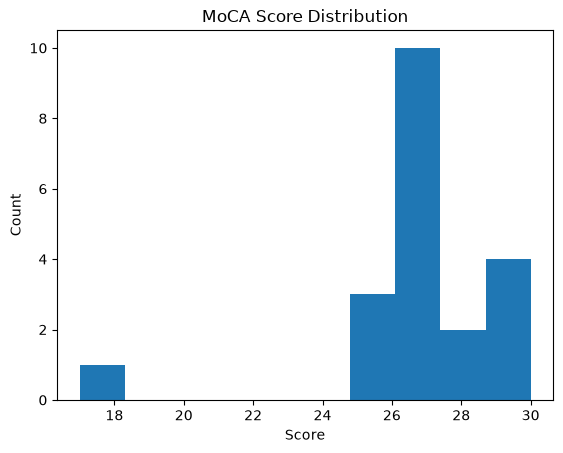

In [22]:
plt.hist(df['MoCA_Score'], bins=10)
plt.title("MoCA Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

# 3. Experiment 1 (All features) 

## 2.1 Train

In [23]:
y = df['MoCA_Score']
df = df.drop(columns=['MoCA_Score'])
X = df

In [26]:
for exp_name, models_list in experiments_list:
    print(f"======================== Experiment : {exp_name} =========================")

    for model in models_list:
        
        pipe = mu.make_model_pipeline(
            mu.make_feature_pipeline(exp_name),
            model()
        )
        
        scores = cross_validate(
            pipe,
            X,
            y,
            cv=5,
            scoring={
                "r2": "r2",
                "mae": "neg_mean_absolute_error",
                "mse": "neg_mean_squared_error",
                "rmse": "neg_root_mean_squared_error"
            }
        )
        
        print(f"Model : {model.__name__}")
        print(f"R² mean : {scores["test_r2"].mean()}")
        print(f"MSE mean : {-scores["test_mse"].mean()}")
        print(f"MAE mean : {-scores["test_mae"].mean()}")
        print("=================================================")

======================== Experiment : all =========================
Model : LinearRegression
R² mean : -2.8470741469667677
MSE mean : 31.384576876359795
MAE mean : 2.64400372279841
Model : Ridge
R² mean : -2.7344832134595953
MSE mean : 30.656518003385763
MAE mean : 2.6101592744332884
Model : RandomForestRegressor
R² mean : -0.5773226058168678
MSE mean : 6.334150000000001
MAE mean : 1.448
Model : XGBRegressor
R² mean : -12.595703264312196
MSE mean : 12.629163506889018
MAE mean : 2.0868907928466798
Model : SVR
R² mean : -0.09705528356437702
MSE mean : 6.696557023065253
MAE mean : 1.3403264138376767
Model : LinearSVR
R² mean : -117.26137825184091
MSE mean : 124.15000000002087
MAE mean : 10.850000000000255


/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Model : MLPRegressor
R² mean : -215.89697888981945
MSE mean : 726.32910467979
MAE mean : 16.776537389441483
Model : Lasso
R² mean : -3.3005339124178135
MSE mean : 9.721864797225868
MAE mean : 1.91855885754252
======================== Experiment : SelectKBest(50) =========================
Model : LinearRegression
R² mean : -69.82334435746637
MSE mean : 39.0818437365891
MAE mean : 3.1086750555541007
Model : Ridge
R² mean : -69.82313230213028
MSE mean : 39.08155009015578
MAE mean : 3.1086105675854596
Model : RandomForestRegressor
R² mean : -0.2545363546463066
MSE mean : 6.005085000000003
MAE mean : 1.3825000000000003
Model : XGBRegressor
R² mean : -12.595703264312196
MSE mean : 12.629163506889018
MAE mean : 2.0868907928466798
Model : SVR
R² mean : -0.16272664520073468
MSE mean : 6.365149604130048
MAE mean : 1.3299894741852707
Model : LinearSVR
R² mean : -104.20657259748825
MSE mean : 59.682717064302366
MAE mean : 4.708138910997632


/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converg

Model : MLPRegressor
R² mean : -3234591.453888283
MSE mean : 2405387.2595440783
MAE mean : 893.0575547954088
Model : Lasso
R² mean : -55.50373246764589
MSE mean : 31.52884936341467
MAE mean : 3.288606198181017
======================== Experiment : SelectKBest(20) =========================
Model : LinearRegression
R² mean : -69.82334435746637
MSE mean : 39.0818437365891
MAE mean : 3.1086750555541007
Model : Ridge
R² mean : -69.82313230213028
MSE mean : 39.08155009015578
MAE mean : 3.1086105675854596


...

/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.114411e+00, tolerance: 1.190e-02
  model = cd_fast.enet_coordinate_descent(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.176309e-02, tolerance: 1.900e-03
  model = cd_fast.enet_coordinate_descent(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the nu

Model : RandomForestRegressor
R² mean : -0.2356938896465966
MSE mean : 5.9912399999999995
MAE mean : 1.4359999999999997
Model : XGBRegressor
R² mean : -12.595703264312196
MSE mean : 12.629163506889018
MAE mean : 2.0868907928466798
Model : SVR
R² mean : -0.16272664520073468
MSE mean : 6.365149604130048
MAE mean : 1.3299894741852707
Model : LinearSVR
R² mean : -39.821799967638114
MSE mean : 29.753189659560945
MAE mean : 4.385310541114521


/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converg

Model : MLPRegressor
R² mean : -3857198.057234118
MSE mean : 3100047.054913082
MAE mean : 1178.4893395685667
Model : Lasso
R² mean : -55.50373246764589
MSE mean : 31.52884936341467
MAE mean : 3.288606198181017


/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.176309e-02, tolerance: 1.900e-03
  model = cd_fast.enet_coordinate_descent(
/home/smira/myproject/detection_AD_with_VR_data/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.631576e-01, tolerance: 1.234e-02
  model = cd_fast.enet_coordinate_descent(


In [25]:
model  = LinearRegression()
scaler = StandardScaler()

y = df['MoCA_Score']
df = df.drop(columns=['MoCA_Score'])
x = df

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)
print(model.coef_, model.intercept_)
y_pred = model.predict(X_test_scaled)

KeyError: 'MoCA_Score'

## 2.2 Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

MAE: 1.533
MSE: 3.411
RMSE: 1.847
R²: -6.042


## 2.3 Test overfitting

In [ ]:
# TRAIN performance
y_train_pred = model.predict(X_train_scaled)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = root_mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print("TRAIN")
print(f"MAE: {train_mae:.3f}")
print(f"RMSE: {train_rmse:.3f}")
print(f"R²: {train_r2:.3f}")

TRAIN
MAE: 0.000
RMSE: 0.000
R²: 1.000


In [ ]:
y.std()
y.describe()

count    20.000000
mean     26.850000
std       2.601113
min      17.000000
25%      27.000000
50%      27.000000
75%      28.000000
max      30.000000
Name: MoCA_Score, dtype: float64

In [ ]:
import numpy as np
print(np.var(y))

6.427499999999999


In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score

dummy = DummyRegressor(strategy="mean")

scores = cross_val_score(dummy, x, y, cv=5, scoring="r2")
print(scores)
print(scores.mean())

[-0.0703125  -0.21052632 -0.11428571 -0.16537468 -0.88020833]
-0.28814150808222105
